In [8]:
!wget -q https://storage.googleapis.com/cloud-samples-data/language/ucaip_ten_dataset.jsonl -O healthcare_dataset.jsonl

print("Healthcare dataset downloaded successfully!")

Healthcare dataset downloaded successfully!


In [3]:
print("Total lines:", len(lines))
print("\nFirst raw line:")
print(lines[0][:1500])

Total lines: 469

First raw line:
{'text_segment_annotations': [{'endOffset': 54, 'startOffset': 27, 'displayName': 'SpecificDisease'}, {'endOffset': 173, 'startOffset': 156, 'displayName': 'SpecificDisease'}, {'endOffset': 179, 'startOffset': 176, 'displayName': 'SpecificDisease'}, {'endOffset': 246, 'startOffset': 243, 'displayName': 'Modifier'}, {'endOffset': 340, 'startOffset': 337, 'displayName': 'Modifier'}, {'endOffset': 698, 'startOffset': 695, 'displayName': 'Modifier'}], 'textContent': '1301937\tMolecular basis of hexosaminidase A deficiency and pseudodeficiency in the Berks County Pennsylvania Dutch.\tFollowing the birth of two infants with Tay-Sachs disease ( TSD ) , a non-Jewish , Pennsylvania Dutch kindred was screened for TSD carriers using the biochemical assay . A high frequency of individuals who appeared to be TSD heterozygotes was detected ( Kelly et al . , 1975 ) . Clinical and biochemical evidence suggested that the increased carrier frequency was due to at least 

In [9]:
import ast

with open("healthcare_dataset.jsonl", "r", encoding="utf-8") as f:
    lines = f.readlines()

records = [
    ast.literal_eval(line.strip())
    for line in lines
    if line.strip()
]

print("Dataset loaded successfully!")
print("Total records:", len(records))

print("\nAvailable fields:")
print(records[0].keys())

Dataset loaded successfully!
Total records: 469

Available fields:
dict_keys(['text_segment_annotations', 'textContent'])


In [5]:
record = records[0]

# Get the medical text
text = record["textContent"]

print("MEDICAL TEXT:")
print("=" * 80)
print(text)

print("\nHEALTHCARE ENTITIES FOUND:")
print("=" * 80)

for annotation in record["text_segment_annotations"]:
    start = annotation["startOffset"]
    end = annotation["endOffset"]
    label = annotation["displayName"]

    entity = text[start:end]

    print(f"{entity}  --->  {label}")

MEDICAL TEXT:
1301937	Molecular basis of hexosaminidase A deficiency and pseudodeficiency in the Berks County Pennsylvania Dutch.	Following the birth of two infants with Tay-Sachs disease ( TSD ) , a non-Jewish , Pennsylvania Dutch kindred was screened for TSD carriers using the biochemical assay . A high frequency of individuals who appeared to be TSD heterozygotes was detected ( Kelly et al . , 1975 ) . Clinical and biochemical evidence suggested that the increased carrier frequency was due to at least two altered alleles for the hexosaminidase A alpha-subunit . We now report two mutant alleles in this Pennsylvania Dutch kindred , and one polymorphism . One allele , reported originally in a French TSD patient ( Akli et al . , 1991 ) , is a GT-- > AT transition at the donor splice-site of intron 9 . The second , a C-- > T transition at nucleotide 739 ( Arg247Trp ) , has been shown by Triggs-Raine et al . ( 1992 ) to be a clinically benign " pseudodeficient " allele associated with red

In [6]:
from collections import Counter

label_counts = Counter()

for record in records:
    for annotation in record["text_segment_annotations"]:
        label_counts[annotation["displayName"]] += 1

print("ENTITY LABEL COUNTS")
print("=" * 40)

for label, count in label_counts.items():
    print(f"{label}: {count}")

ENTITY LABEL COUNTS
SpecificDisease: 2313
Modifier: 1024
DiseaseClass: 592
CompositeMention: 83


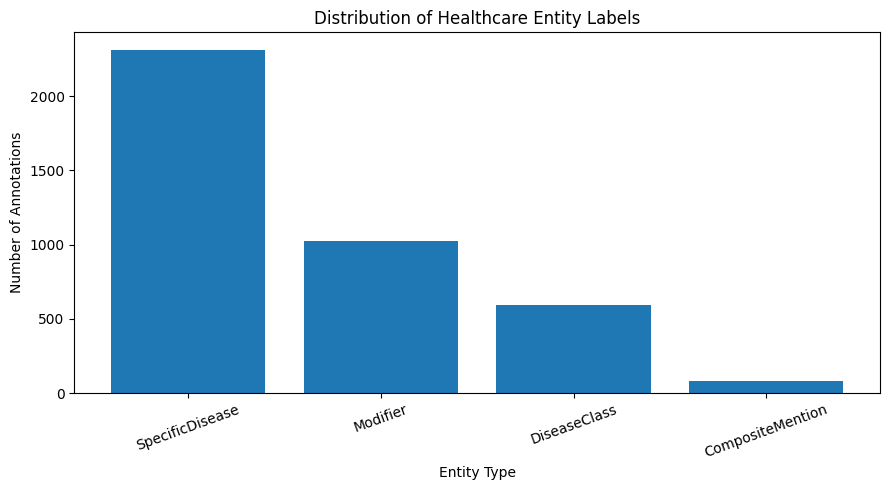

In [7]:
import matplotlib.pyplot as plt

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(9, 5))
plt.bar(labels, counts)

plt.title("Distribution of Healthcare Entity Labels")
plt.xlabel("Entity Type")
plt.ylabel("Number of Annotations")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# First separate 80% training and 20% temporary data
train_records, temp_records = train_test_split(
    records,
    test_size=0.20,
    random_state=42
)

# Divide the remaining 20% equally:
# 10% validation and 10% testing
validation_records, test_records = train_test_split(
    temp_records,
    test_size=0.50,
    random_state=42
)

print("DATASET SPLIT")
print("=" * 40)

print("Training records:  ", len(train_records))
print("Validation records:", len(validation_records))
print("Testing records:   ", len(test_records))

print("\nTotal records:",
      len(train_records)
      + len(validation_records)
      + len(test_records))

DATASET SPLIT
Training records:   375
Validation records: 47
Testing records:    47

Total records: 469


In [6]:
!pip -q install transformers datasets evaluate seqeval accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00


In [11]:
!pip -q install sentencepiece

In [11]:
from transformers import BertTokenizer

model_name = "dmis-lab/biobert-base-cased-v1.1"

tokenizer = BertTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [12]:
entity_types = [
    "SpecificDisease",
    "DiseaseClass",
    "Modifier",
    "CompositeMention"
]

label_list = ["O"]

for entity in entity_types:
    label_list.append(f"B-{entity}")
    label_list.append(f"I-{entity}")

label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print("MODEL LABELS")
print("=" * 50)

for label, number in label2id.items():
    print(f"{number}: {label}")

print("\nTotal labels:", len(label_list))

MODEL LABELS
0: O
1: B-SpecificDisease
2: I-SpecificDisease
3: B-DiseaseClass
4: I-DiseaseClass
5: B-Modifier
6: I-Modifier
7: B-CompositeMention
8: I-CompositeMention

Total labels: 9


In [9]:
from transformers import BertTokenizerFast

fast_tokenizer = BertTokenizerFast.from_pretrained(
    "dmis-lab/biobert-base-cased-v1.1"
)

test_text = "The patient was diagnosed with Tay-Sachs disease."

test_encoding = fast_tokenizer(
    test_text,
    return_offsets_mapping=True
)

print("Fast tokenizer loaded successfully!")
print("\nTokens:")
print(fast_tokenizer.convert_ids_to_tokens(test_encoding["input_ids"]))

print("\nCharacter offsets:")
print(test_encoding["offset_mapping"])

Fast tokenizer loaded successfully!

Tokens:
['[CLS]', 'the', 'patient', 'was', 'diagnosed', 'with', 'ta', '##y', '-', 'sa', '##chs', 'disease', '.', '[SEP]']

Character offsets:
[(0, 0), (0, 3), (4, 11), (12, 15), (16, 25), (26, 30), (31, 33), (33, 34), (34, 35), (35, 37), (37, 40), (41, 48), (48, 49), (0, 0)]


In [10]:
overlap_count = 0
same_span_different_label = 0
records_with_overlaps = 0

for record in records:
    annotations = record["text_segment_annotations"]
    record_has_overlap = False

    for i in range(len(annotations)):
        for j in range(i + 1, len(annotations)):
            a = annotations[i]
            b = annotations[j]

            # Check whether two annotation spans overlap
            if (a["startOffset"] < b["endOffset"] and
                b["startOffset"] < a["endOffset"]):

                overlap_count += 1
                record_has_overlap = True

                # Same exact text span but different entity labels
                if (
                    a["startOffset"] == b["startOffset"]
                    and a["endOffset"] == b["endOffset"]
                    and a["displayName"] != b["displayName"]
                ):
                    same_span_different_label += 1

    if record_has_overlap:
        records_with_overlaps += 1


print("ANNOTATION OVERLAP CHECK")
print("=" * 45)
print("Total overlapping annotation pairs:", overlap_count)
print("Same span with different labels:", same_span_different_label)
print("Records containing overlaps:", records_with_overlaps)
print("Total records:", len(records))

ANNOTATION OVERLAP CHECK
Total overlapping annotation pairs: 0
Same span with different labels: 0
Records containing overlaps: 0
Total records: 469


In [9]:
def encode_record(record):
    text = record["textContent"]
    annotations = record["text_segment_annotations"]

    # Tokenize and keep character positions
    encoding = fast_tokenizer(
        text,
        truncation=True,
        max_length=512,
        return_offsets_mapping=True
    )

    offsets = encoding["offset_mapping"]

    # Start every token as O
    labels = [label2id["O"]] * len(offsets)

    # Special tokens such as [CLS] and [SEP] are ignored during training
    for i, (start, end) in enumerate(offsets):
        if start == end:
            labels[i] = -100

    # Match healthcare annotations to BioBERT tokens
    for annotation in annotations:
        entity_start = annotation["startOffset"]
        entity_end = annotation["endOffset"]
        entity_type = annotation["displayName"]

        first_token = True

        for i, (token_start, token_end) in enumerate(offsets):

            # Skip special tokens
            if token_start == token_end:
                continue

            # Check whether token overlaps the annotated entity
            if token_start < entity_end and token_end > entity_start:

                if first_token:
                    labels[i] = label2id[f"B-{entity_type}"]
                    first_token = False
                else:
                    labels[i] = label2id[f"I-{entity_type}"]

    encoding["labels"] = labels

    # Offset mapping is only needed for alignment, not model training
    encoding.pop("offset_mapping")

    return encoding


print("BIO conversion function created successfully!")

BIO conversion function created successfully!


In [12]:
sample_encoding = encode_record(records[0])

tokens = fast_tokenizer.convert_ids_to_tokens(sample_encoding["input_ids"])
label_ids = sample_encoding["labels"]

print("TOKEN LABEL CHECK")
print("=" * 70)

for token, label_id in zip(tokens, label_ids):
    if label_id == -100:
        label_name = "IGNORED"
    else:
        label_name = id2label[label_id]

    print(f"{token:20} -> {label_name}")

TOKEN LABEL CHECK
[CLS]                -> IGNORED
130                  -> O
##19                 -> O
##37                 -> O
molecular            -> O
basis                -> O
of                   -> O
he                   -> B-SpecificDisease
##x                  -> I-SpecificDisease
##osa                -> I-SpecificDisease
##mini               -> I-SpecificDisease
##das                -> I-SpecificDisease
##e                  -> I-SpecificDisease
a                    -> I-SpecificDisease
deficiency           -> I-SpecificDisease
and                  -> O
pseudo               -> O
##de                 -> O
##ficiency           -> O
in                   -> O
the                  -> O
be                   -> O
##rks                -> O
county               -> O
pen                  -> O
##ns                 -> O
##yl                 -> O
##vani               -> O
##a                  -> O
du                   -> O
##tch                -> O
.                    -> O
following       

In [13]:
token_lengths = []

for record in records:
    tokens = fast_tokenizer(
        record["textContent"],
        add_special_tokens=True,
        truncation=False
    )

    token_lengths.append(len(tokens["input_ids"]))


print("DOCUMENT LENGTH CHECK")
print("=" * 45)
print("Total records:", len(token_lengths))
print("Shortest document:", min(token_lengths), "tokens")
print("Longest document:", max(token_lengths), "tokens")
print("Average document length:", round(sum(token_lengths) / len(token_lengths), 2), "tokens")

over_512 = sum(length > 512 for length in token_lengths)

print("\nDocuments longer than 512 tokens:", over_512)

DOCUMENT LENGTH CHECK
Total records: 469
Shortest document: 81 tokens
Longest document: 774 tokens
Average document length: 319.11 tokens

Documents longer than 512 tokens: 21


In [13]:
def encode_record_with_chunks(record):
    text = record["textContent"]
    annotations = record["text_segment_annotations"]

    # Split long documents into overlapping BioBERT chunks
    encodings = fast_tokenizer(
        text,
        truncation=True,
        max_length=512,
        stride=64,
        return_overflowing_tokens=True,
        return_offsets_mapping=True
    )

    chunks = []

    for chunk_index in range(len(encodings["input_ids"])):

        input_ids = encodings["input_ids"][chunk_index]
        attention_mask = encodings["attention_mask"][chunk_index]
        offsets = encodings["offset_mapping"][chunk_index]

        # Start with O labels
        labels = [label2id["O"]] * len(input_ids)

        # Ignore special tokens
        for i, (start, end) in enumerate(offsets):
            if start == end:
                labels[i] = -100

        # Align healthcare annotations with tokens
        for annotation in annotations:

            entity_start = annotation["startOffset"]
            entity_end = annotation["endOffset"]
            entity_type = annotation["displayName"]

            entity_tokens = []

            for i, (token_start, token_end) in enumerate(offsets):

                if token_start == token_end:
                    continue

                if token_start < entity_end and token_end > entity_start:
                    entity_tokens.append(i)

            if entity_tokens:

                first = entity_tokens[0]

                labels[first] = label2id[f"B-{entity_type}"]

                for i in entity_tokens[1:]:
                    labels[i] = label2id[f"I-{entity_type}"]

        chunks.append({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        })

    return chunks


print("Long-document preprocessing function created successfully!")

Long-document preprocessing function created successfully!


In [15]:
from transformers import BertTokenizerFast

model_name = "dmis-lab/biobert-base-cased-v1.1"

fast_tokenizer = BertTokenizerFast.from_pretrained(model_name)

print("Fast tokenizer restored successfully!")
print("Tokenizer type:", type(fast_tokenizer).__name__)

Fast tokenizer restored successfully!
Tokenizer type: BertTokenizer


In [16]:
from datasets import Dataset

def build_chunked_dataset(record_list):
    all_chunks = []

    for record in record_list:
        chunks = encode_record_with_chunks(record)
        all_chunks.extend(chunks)

    return Dataset.from_list(all_chunks)


train_dataset = build_chunked_dataset(train_records)
validation_dataset = build_chunked_dataset(validation_records)
test_dataset = build_chunked_dataset(test_records)


print("BIOBERT DATASETS CREATED")
print("=" * 45)
print("Training chunks:  ", len(train_dataset))
print("Validation chunks:", len(validation_dataset))
print("Testing chunks:   ", len(test_dataset))
print("\nDataset features:")
print(train_dataset.features)

BIOBERT DATASETS CREATED
Training chunks:   392
Validation chunks: 49
Testing chunks:    49

Dataset features:
{'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


In [17]:
from transformers import BertConfig, BertForTokenClassification

# Create a BERT configuration for our 9 BIO labels
config = BertConfig.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

# Load BioBERT as a token-classification model
model = BertForTokenClassification.from_pretrained(
    model_name,
    config=config
)

print("BioBERT model loaded successfully!")
print("Number of output labels:", model.config.num_labels)

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	

BioBERT model loaded successfully!
Number of output labels: 9


In [5]:
import torch

print("COMPUTING DEVICE")
print("=" * 40)

if torch.cuda.is_available():
    print("GPU available: YES")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU available: NO")
    print("Current device: CPU")

COMPUTING DEVICE
GPU available: YES
GPU: Tesla T4


In [12]:
from transformers import BertTokenizer, BertTokenizerFast

model_name = "dmis-lab/biobert-base-cased-v1.1"

tokenizer = BertTokenizer.from_pretrained(model_name)

fast_tokenizer = BertTokenizerFast.from_pretrained(model_name)

print("Tokenizers restored!")
print("Fast tokenizer available:", fast_tokenizer is not None)

Tokenizers restored!
Fast tokenizer available: True


In [13]:
from datasets import Dataset

def build_chunked_dataset(record_list):
    all_chunks = []

    for record in record_list:
        chunks = encode_record_with_chunks(record)
        all_chunks.extend(chunks)

    return Dataset.from_list(all_chunks)


train_dataset = build_chunked_dataset(train_records)
validation_dataset = build_chunked_dataset(validation_records)
test_dataset = build_chunked_dataset(test_records)

print("BIOBERT DATASETS RESTORED")
print("=" * 45)
print("Training chunks:", len(train_dataset))
print("Validation chunks:", len(validation_dataset))
print("Testing chunks:", len(test_dataset))

BIOBERT DATASETS RESTORED
Training chunks: 392
Validation chunks: 49
Testing chunks: 49


In [14]:
from transformers import BertConfig, BertForTokenClassification

config = BertConfig.from_pretrained(
    model_name,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

model = BertForTokenClassification.from_pretrained(
    model_name,
    config=config
)

print("BioBERT model restored successfully!")
print("Number of labels:", model.config.num_labels)

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

[transformers] BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	

BioBERT model restored successfully!
Number of labels: 9


model.safetensors: downloading bytes:           |  0.00B            

In [15]:
import torch

print("FINAL RESTORE CHECK")
print("=" * 45)
print("Training chunks:", len(train_dataset))
print("Validation chunks:", len(validation_dataset))
print("Testing chunks:", len(test_dataset))
print("Number of labels:", model.config.num_labels)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

FINAL RESTORE CHECK
Training chunks: 392
Validation chunks: 49
Testing chunks: 49
Number of labels: 9
GPU available: True
GPU: Tesla T4


In [18]:
import torch
from transformers import (
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer
)

# Automatically pads each batch to the correct length
data_collator = DataCollatorForTokenClassification(
    tokenizer=fast_tokenizer
)

training_args = TrainingArguments(
    output_dir="./biobert_healthcare_ner",

    learning_rate=2e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    # Effective batch size = 4 × 2 = 8
    gradient_accumulation_steps=2,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=20,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # T4 GPU supports mixed-precision training
    fp16=torch.cuda.is_available(),

    report_to="none",
    save_total_limit=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator
)

print("Training configuration created successfully!")
print("Epochs:", training_args.num_train_epochs)
print("GPU training:", torch.cuda.is_available())

Training configuration created successfully!
Epochs: 3
GPU training: True


In [19]:
print("Starting BioBERT training...")
print("=" * 50)

train_result = trainer.train()

print("\nBioBERT training completed successfully!")
print("=" * 50)

print("Training results:")
for key, value in train_result.metrics.items():
    print(f"{key}: {value}")

Starting BioBERT training...


Epoch,Training Loss,Validation Loss
1,0.778798,0.258103
2,0.440759,0.166165
3,0.288571,0.144765


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


BioBERT training completed successfully!
Training results:
train_runtime: 205.1143
train_samples_per_second: 5.733
train_steps_per_second: 0.717
total_flos: 254741672287224.0
train_loss: 0.6890389903062055
epoch: 3.0


In [20]:
from google.colab import drive

# Connect Google Drive
drive.mount('/content/drive')

# Permanent folder for our trained model
save_path = "/content/drive/MyDrive/BioBERT_Healthcare_NER"

# Save trained model and tokenizer
trainer.save_model(save_path)
fast_tokenizer.save_pretrained(save_path)

print("Model saved permanently to Google Drive!")
print("Saved at:", save_path)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved permanently to Google Drive!
Saved at: /content/drive/MyDrive/BioBERT_Healthcare_NER


In [21]:
print("TEST SET EVALUATION")
print("=" * 50)

test_results = trainer.evaluate(test_dataset)

for key, value in test_results.items():
    print(f"{key}: {value}")

TEST SET EVALUATION


Training Loss,Validation Loss,Epoch
0.288571,0.145932,3


eval_loss: 0.14593186974525452


In [22]:
import numpy as np
from seqeval.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

predictions = trainer.predict(test_dataset)

predicted_ids = np.argmax(predictions.predictions, axis=2)
true_label_ids = predictions.label_ids

true_predictions = []
true_labels = []

for prediction, labels in zip(predicted_ids, true_label_ids):

    predicted_sequence = []
    true_sequence = []

    for predicted_id, true_id in zip(prediction, labels):

        # Ignore padding and special tokens
        if true_id != -100:
            predicted_sequence.append(id2label[int(predicted_id)])
            true_sequence.append(id2label[int(true_id)])

    true_predictions.append(predicted_sequence)
    true_labels.append(true_sequence)


precision = precision_score(true_labels, true_predictions)
recall = recall_score(true_labels, true_predictions)
f1 = f1_score(true_labels, true_predictions)

print("FINAL TEST METRICS")
print("=" * 50)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nDETAILED ENTITY REPORT")
print("=" * 50)
print(classification_report(true_labels, true_predictions))

FINAL TEST METRICS
Precision: 0.4518
Recall:    0.5859
F1-score:  0.5102

DETAILED ENTITY REPORT
                  precision    recall  f1-score   support

CompositeMention       0.00      0.00      0.00         2
    DiseaseClass       0.28      0.19      0.23        68
        Modifier       0.27      0.24      0.25        91
 SpecificDisease       0.52      0.85      0.64       223

       micro avg       0.45      0.59      0.51       384
       macro avg       0.27      0.32      0.28       384
    weighted avg       0.41      0.59      0.47       384



In [23]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the best model selected during training
model = trainer.model.to(device)
model.eval()

def extract_healthcare_entities(text):

    encoding = fast_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        return_offsets_mapping=True
    )

    offsets = encoding.pop("offset_mapping")[0].tolist()

    model_inputs = {
        key: value.to(device)
        for key, value in encoding.items()
    }

    with torch.no_grad():
        output = model(**model_inputs)

    probabilities = torch.softmax(output.logits, dim=-1)[0]

    predicted_ids = torch.argmax(
        probabilities,
        dim=-1
    ).cpu().tolist()

    confidences = torch.max(
        probabilities,
        dim=-1
    ).values.cpu().tolist()

    entities = []
    current_entity = None

    for (start, end), predicted_id, confidence in zip(
        offsets,
        predicted_ids,
        confidences
    ):

        # Ignore [CLS], [SEP], and padding
        if start == end:
            continue

        label = id2label[predicted_id]

        if label == "O":

            if current_entity is not None:
                current_entity["confidence"] = (
                    sum(current_entity["scores"])
                    / len(current_entity["scores"])
                )

                del current_entity["scores"]
                entities.append(current_entity)
                current_entity = None

            continue

        prefix, entity_type = label.split("-", 1)

        if (
            prefix == "B"
            or current_entity is None
            or current_entity["type"] != entity_type
        ):

            if current_entity is not None:
                current_entity["confidence"] = (
                    sum(current_entity["scores"])
                    / len(current_entity["scores"])
                )

                del current_entity["scores"]
                entities.append(current_entity)

            current_entity = {
                "text": text[start:end],
                "type": entity_type,
                "start": start,
                "end": end,
                "scores": [confidence]
            }

        else:
            current_entity["end"] = end
            current_entity["text"] = text[
                current_entity["start"]:end
            ]

            current_entity["scores"].append(confidence)

    if current_entity is not None:
        current_entity["confidence"] = (
            sum(current_entity["scores"])
            / len(current_entity["scores"])
        )

        del current_entity["scores"]
        entities.append(current_entity)

    return entities


print("Healthcare prediction function created successfully!")

Healthcare prediction function created successfully!


In [24]:
def human_review_system(text, confidence_threshold=0.70):

    entities = extract_healthcare_entities(text)

    print("HUMAN-IN-THE-LOOP HEALTHCARE AI")
    print("=" * 65)
    print("Input Medical Text:")
    print(text)

    print("\nIDENTIFIED HEALTHCARE INFORMATION")
    print("=" * 65)

    if len(entities) == 0:
        print("No healthcare entities detected.")
        return

    for entity in entities:

        confidence = entity["confidence"]

        if confidence >= confidence_threshold:
            status = "AUTO-ACCEPTED"
        else:
            status = "HUMAN REVIEW REQUIRED"

        print(f"Entity     : {entity['text']}")
        print(f"Type       : {entity['type']}")
        print(f"Confidence : {confidence:.2%}")
        print(f"Decision   : {status}")
        print("-" * 65)


# Test on new healthcare text
test_text = """
The patient was diagnosed with Tay-Sachs disease.
Her brother has Huntington disease.
The family is undergoing genetic counseling.
"""

human_review_system(
    test_text,
    confidence_threshold=0.70
)

HUMAN-IN-THE-LOOP HEALTHCARE AI
Input Medical Text:

The patient was diagnosed with Tay-Sachs disease.
Her brother has Huntington disease.
The family is undergoing genetic counseling.


IDENTIFIED HEALTHCARE INFORMATION
Entity     : Tay-Sachs disease
Type       : SpecificDisease
Confidence : 65.28%
Decision   : HUMAN REVIEW REQUIRED
-----------------------------------------------------------------
Entity     : ton disease
Type       : SpecificDisease
Confidence : 51.42%
Decision   : HUMAN REVIEW REQUIRED
-----------------------------------------------------------------
